# 10 — Deep Learning Foundations & PyTorch Tensors

`08_neural_nets_intro` used scikit-learn's `MLPClassifier` to build a first
intuition for neural networks — but sklearn's MLP is a black box: you call
`.fit()` and never see the tensors, the computation graph, or the gradients
that make training work. This notebook (and the rest of modules 10-19)
switches to **PyTorch**, where those internals are visible and directly
programmable.

**Why this matters before going further:** every deep learning concept from
here on (CNNs, RNNs, Transformers) is built out of the same two primitives
covered in this notebook — **tensors** and **autograd** — so it's worth
building real confidence in them on tiny, fully-understood examples first.

**Covered:**
1. Why "deep" learning needs more than sklearn's MLP can offer
2. Tensors: creation, shape, dtype, indexing, broadcasting, NumPy interop
3. Autograd: computation graphs and `.backward()`
4. Verifying autograd against hand-computed gradients
5. A forward pass built from raw tensors (the bridge to `nn.Module` in Module 11)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sns.set_theme(style="whitegrid")
torch.manual_seed(10)
rng = np.random.default_rng(10)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")  # expect False in this CPU-only environment

PyTorch version: 2.13.0+cu130
CUDA available: False


## 1. Why Move Past sklearn's MLP?

Recapping the comparison table from `08_neural_nets_intro`: sklearn's MLP
only offers fully-connected layers, runs on CPU only, and gives you no
control over the computation graph. PyTorch removes all three limits:

- **Any architecture** — convolutions, recurrence, attention, or anything you
  can express as tensor operations (modules 14, 16, 17 all lean on this).
- **GPU acceleration** — the same code scales to hardware this environment
  doesn't have, without changing the model definition.
- **A visible, differentiable computation graph** — you can inspect exactly
  how a gradient was computed, not just trust that `.fit()` did the right
  thing.

The rest of this notebook builds direct evidence for that third point.

## 2. Tensors

**Theory.** A tensor is PyTorch's core data structure — conceptually a
NumPy array, but one that can track gradients and run on a GPU. Nearly
everything in PyTorch (data, weights, activations) is a tensor.

In [2]:
# Creation
t_from_list = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
t_zeros = torch.zeros(2, 3)
t_rand = torch.rand(2, 3)

print("From list:\n", t_from_list)
print("\nShape:", t_from_list.shape, "| dtype:", t_from_list.dtype)
print("\nZeros:\n", t_zeros)
print("\nRandom:\n", t_rand)

From list:
 tensor([[1., 2.],
        [3., 4.]])

Shape: torch.Size([2, 2]) | dtype: torch.float32

Zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

Random:
 tensor([[0.4581, 0.4829, 0.3125],
        [0.6150, 0.2139, 0.4118]])


In [3]:
# NumPy interop: tensors and arrays can share memory via from_numpy / .numpy()
np_array = rng.normal(size=(3, 3))
tensor_from_np = torch.from_numpy(np_array)
back_to_np = tensor_from_np.numpy()

print("NumPy -> Tensor -> NumPy round-trip matches:", np.allclose(np_array, back_to_np))

NumPy -> Tensor -> NumPy round-trip matches: True


In [4]:
# Indexing, reshaping, and broadcasting -- the same rules as NumPy
x = torch.arange(12).reshape(3, 4).float()
print("x:\n", x)
print("\nx[1, :]  (row 1):", x[1, :])
print("x[:, 2]  (col 2):", x[:, 2])
print("\nreshaped to (4, 3):\n", x.reshape(4, 3))

# Broadcasting: a (3,1) column added to a (1,4) row produces a (3,4) grid
col = torch.tensor([[0.0], [10.0], [20.0]])
row = torch.tensor([[1.0, 2.0, 3.0, 4.0]])
print("\nBroadcasting (3,1) + (1,4) ->\n", col + row)

x:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

x[1, :]  (row 1): tensor([4., 5., 6., 7.])
x[:, 2]  (col 2): tensor([ 2.,  6., 10.])

reshaped to (4, 3):
 tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])

Broadcasting (3,1) + (1,4) ->
 tensor([[ 1.,  2.,  3.,  4.],
        [11., 12., 13., 14.],
        [21., 22., 23., 24.]])


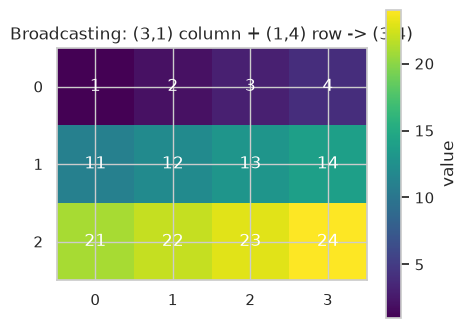

In [5]:
# Visualize broadcasting so the shapes are intuitive, not just numbers
fig, ax = plt.subplots(figsize=(5, 4))
result = (col + row).numpy()
im = ax.imshow(result, cmap="viridis")
for i in range(result.shape[0]):
    for j in range(result.shape[1]):
        ax.text(j, i, f"{result[i, j]:.0f}", ha="center", va="center", color="white")
ax.set_xticks(range(4)); ax.set_yticks(range(3))
ax.set_title("Broadcasting: (3,1) column + (1,4) row -> (3,4)")
plt.colorbar(im, label="value")
plt.show()

## 3. Autograd: Computation Graphs & `.backward()`

**Theory.** Setting `requires_grad=True` on a tensor tells PyTorch to track
every operation applied to it in a **computation graph**. Calling
`.backward()` on a final scalar output walks that graph backward (the chain
rule, applied automatically) and fills in `.grad` on every tensor that
requested it. This *is* backpropagation — the same mechanism trains every
network in this syllabus, no matter how deep.

Start with the simplest possible case: `y = x^2`, whose derivative
`dy/dx = 2x` we can check by hand.

In [6]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()

print(f"x = {x.item()}")
print(f"y = x^2 = {y.item()}")
print(f"autograd's dy/dx = {x.grad.item()}")
print(f"hand-computed 2x = {2 * x.item()}")

x = 3.0
y = x^2 = 9.0
autograd's dy/dx = 6.0
hand-computed 2x = 6.0


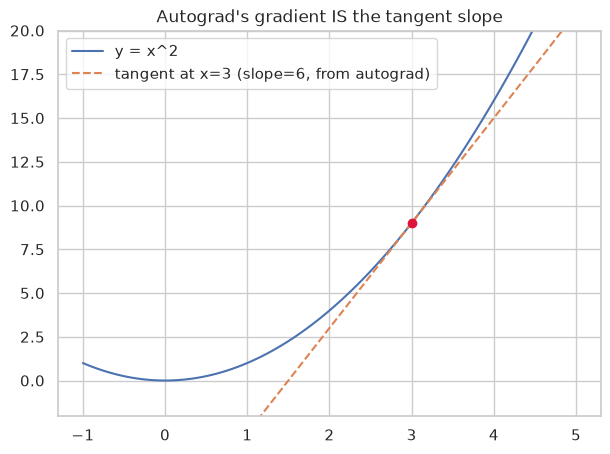

In [7]:
# Visualize: the tangent line's slope at x=3 should exactly match x.grad
x_plot = np.linspace(-1, 5, 100)
y_plot = x_plot ** 2

x_point, y_point, slope = x.item(), y.item(), x.grad.item()
tangent = y_point + slope * (x_plot - x_point)

plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, label="y = x^2")
plt.plot(x_plot, tangent, linestyle="--", label=f"tangent at x={x_point:.0f} (slope={slope:.0f}, from autograd)")
plt.scatter([x_point], [y_point], color="crimson", zorder=5)
plt.ylim(-2, 20)
plt.legend()
plt.title("Autograd's gradient IS the tangent slope")
plt.show()

Now a slightly richer example: a function of two variables, so we can see
the graph branch and recombine.

In [8]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(5.0, requires_grad=True)
c = a * b        # c = 10
d = c + a ** 2   # d = 10 + 4 = 14
d.backward()

print(f"d = a*b + a^2 = {d.item()}")
print(f"autograd dd/da = {a.grad.item()}  (hand-computed: b + 2a = {b.item() + 2*a.item()})")
print(f"autograd dd/db = {b.grad.item()}  (hand-computed: a = {a.item()})")

d = a*b + a^2 = 14.0
autograd dd/da = 9.0  (hand-computed: b + 2a = 9.0)
autograd dd/db = 2.0  (hand-computed: a = 2.0)


## 4. Verifying Autograd Against Hand-Computed Gradients

To fully trust autograd before relying on it for real networks, let's fit a
**linear regression** two ways on the same synthetic data — once with
gradients derived and coded by hand (plain NumPy), once with PyTorch
autograd doing the derivative for us — and confirm they agree at every step.

In [9]:
# Synthetic data: y = 3x + 2 + noise
X_np = rng.uniform(-3, 3, size=(50, 1))
y_np = 3 * X_np + 2 + rng.normal(scale=0.5, size=(50, 1))

def manual_gradient_step(w, b, X, y, lr):
    y_pred = w * X + b
    error = y_pred - y
    grad_w = (2 * error * X).mean()
    grad_b = (2 * error).mean()
    return w - lr * grad_w, b - lr * grad_b

def autograd_gradient_step(w, b, X, y, lr):
    y_pred = w * X + b
    loss = ((y_pred - y) ** 2).mean()
    loss.backward()
    with torch.no_grad():
        w_new = w - lr * w.grad
        b_new = b - lr * b.grad
    w_new.requires_grad_(True)
    b_new.requires_grad_(True)
    return w_new, b_new

# Manual (NumPy) training
w_manual, b_manual = 0.0, 0.0
for _ in range(200):
    w_manual, b_manual = manual_gradient_step(w_manual, b_manual, X_np, y_np, lr=0.05)

# PyTorch autograd training
X_t = torch.from_numpy(X_np).float()
y_t = torch.from_numpy(y_np).float()
w_auto = torch.tensor(0.0, requires_grad=True)
b_auto = torch.tensor(0.0, requires_grad=True)
for _ in range(200):
    w_auto, b_auto = autograd_gradient_step(w_auto, b_auto, X_t, y_t, lr=0.05)

print(f"Manual gradient descent:   w={w_manual:.4f}, b={b_manual:.4f}")
print(f"Autograd gradient descent: w={w_auto.item():.4f}, b={b_auto.item():.4f}")
print(f"True generating values:    w=3.0000, b=2.0000")

Manual gradient descent:   w=2.9831, b=1.9295
Autograd gradient descent: w=2.9831, b=1.9295
True generating values:    w=3.0000, b=2.0000


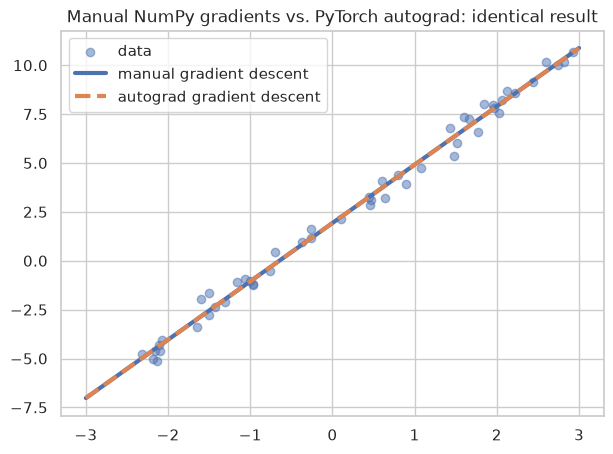

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(X_np, y_np, alpha=0.5, label="data")
x_line = np.linspace(-3, 3, 50)
plt.plot(x_line, w_manual * x_line + b_manual, label="manual gradient descent", linewidth=3)
plt.plot(x_line, w_auto.item() * x_line + b_auto.item(), linestyle="--", label="autograd gradient descent", linewidth=3)
plt.legend()
plt.title("Manual NumPy gradients vs. PyTorch autograd: identical result")
plt.show()

Both approaches converge to essentially the same line — autograd isn't
doing anything magical, it's automating exactly the derivative you'd derive
by hand, which is precisely why it's safe to rely on for networks too deep
to differentiate manually.

## 5. A Forward Pass From Raw Tensors

Before wrapping things in `nn.Module` (Module 11), it's worth building one
tiny network's forward pass from raw tensors, so the abstraction that comes
next doesn't hide anything conceptually new.

In [11]:
torch.manual_seed(0)

# A "network": 2 inputs -> hidden layer of 4 (ReLU) -> 1 output
W1 = torch.randn(2, 4, requires_grad=True)
b1 = torch.zeros(4, requires_grad=True)
W2 = torch.randn(4, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

def forward(x):
    hidden = torch.relu(x @ W1 + b1)
    return hidden @ W2 + b2

x_sample = torch.tensor([[1.0, -2.0]])
output = forward(x_sample)
print("Input:", x_sample)
print("Output:", output)

loss = (output - torch.tensor([[5.0]])) ** 2
loss.backward()
print(f"\nGradient shapes -- W1: {W1.grad.shape}, b1: {b1.grad.shape}, W2: {W2.grad.shape}, b2: {b2.grad.shape}")
print("A single .backward() call computed gradients for every parameter in the network.")

Input: tensor([[ 1., -2.]])
Output: tensor([[-3.6784]], grad_fn=<AddBackward0>)

Gradient shapes -- W1: torch.Size([2, 4]), b1: torch.Size([4]), W2: torch.Size([4, 1]), b2: torch.Size([1])
A single .backward() call computed gradients for every parameter in the network.


This *is* a neural network — matrix multiply, add bias, non-linearity,
repeat — just spelled out manually. `nn.Module` in Module 11 packages
exactly this pattern (weights, forward pass, parameter tracking) into a
reusable class, and `torch.optim` replaces the manual `w - lr * w.grad`
update step with proper optimizers (SGD, Adam, ...) — but nothing about the
underlying mechanism changes.

## Exercises

1. Change `y = x ** 2` in section 3 to `y = x ** 3` and verify `x.grad` matches the hand-derivative `3x^2`.
2. In section 4, change the learning rate `lr` from `0.05` to `0.5` — does gradient descent still converge, or does it diverge? Why might autograd-based training be more sensitive to learning rate than you'd expect?
3. In section 5, add a second hidden layer (4 -> 4, ReLU) before the output layer, and confirm `.backward()` still produces gradients for every weight matrix.

## Key Takeaways

- PyTorch tensors are NumPy arrays that can track gradients and (on other hardware) run on a GPU — the same broadcasting/indexing/reshaping rules apply.
- Autograd builds a computation graph as operations run, then computes exact gradients for every tracked tensor with a single `.backward()` call.
- Autograd's gradients match hand-derived ones exactly — it's automating calculus you could do yourself, just at a scale you couldn't.
- A neural network's forward pass is just chained matrix multiplies, bias adds, and non-linearities — everything `nn.Module` and `torch.optim` add in Module 11 is convenience on top of this same mechanism.